**Imports**

In [3]:
import os
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

from skimage.filters import threshold_sauvola
from tqdm import tqdm


**Metrics**

In [5]:
def dice_score(pred, gt):
    intersection = np.sum(pred * gt)
    return (2.0 * intersection) / (np.sum(pred) + np.sum(gt) + 1e-8)

def jaccard_score(pred, gt):
    intersection = np.sum(pred * gt)
    union = np.sum((pred + gt) > 0)
    return intersection / (union + 1e-8)


**Paths**

In [17]:
image_dir = r'C:\V\sem_6_notes\DL_MedicalImage_processing\BrainTumorMRISegment\BrainTumorMRISegmentationDataSet\images'
mask_dir  = r'C:\V\sem_6_notes\DL_MedicalImage_processing\BrainTumorMRISegment\BrainTumorMRISegmentationDataSet\masks'

**Processing Parameters**

In [18]:
window_size = 25
k = 0.2

kernel = np.ones((3,3), np.uint8)


**Main Evaluation Loop**

In [19]:
dice_otsu = []
dice_sauvola = []

jaccard_otsu = []
jaccard_sauvola = []

files = os.listdir(image_dir)

for file in tqdm(files):

    img_path = os.path.join(image_dir, file)
    mask_path = os.path.join(mask_dir, file)

    image = cv.imread(img_path, 0)
    gt_mask = cv.imread(mask_path, 0)

    if image is None or gt_mask is None:
        continue

    gt_bin = (gt_mask > 0).astype(np.uint8)

    # ---------------- OTSU ----------------
    _, otsu_mask = cv.threshold(
        image, 0, 255,
        cv.THRESH_BINARY + cv.THRESH_OTSU
    )

    otsu_mask = cv.morphologyEx(otsu_mask, cv.MORPH_OPEN, kernel)
    otsu_bin = (otsu_mask > 0).astype(np.uint8)

    # ---------------- SAUVOLA ----------------
    thresh_sauvola = threshold_sauvola(
        image,
        window_size=window_size,
        k=k
    )

    sauvola_mask = (image > thresh_sauvola).astype(np.uint8) * 255
    sauvola_mask = cv.morphologyEx(sauvola_mask, cv.MORPH_OPEN, kernel)
    sauvola_bin = (sauvola_mask > 0).astype(np.uint8)

    # ---------------- METRICS ----------------
    dice_otsu.append(dice_score(otsu_bin, gt_bin))
    dice_sauvola.append(dice_score(sauvola_bin, gt_bin))

    jaccard_otsu.append(jaccard_score(otsu_bin, gt_bin))
    jaccard_sauvola.append(jaccard_score(sauvola_bin, gt_bin))


100%|██████████| 3064/3064 [03:32<00:00, 14.42it/s]


**Aggregation Results**

In [20]:
print("===== Average Performance =====")

print(f"Otsu Dice      : {np.mean(dice_otsu):.4f}")
print(f"Sauvola Dice   : {np.mean(dice_sauvola):.4f}")

print(f"Otsu Jaccard   : {np.mean(jaccard_otsu):.4f}")
print(f"Sauvola Jaccard: {np.mean(jaccard_sauvola):.4f}")


===== Average Performance =====
Otsu Dice      : 0.0708
Sauvola Dice   : 0.0477
Otsu Jaccard   : 0.0377
Sauvola Jaccard: 0.0249


**Visualize One Example**

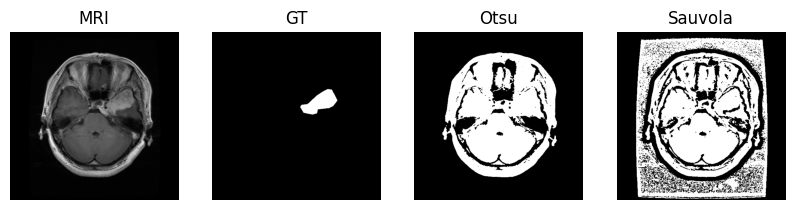

In [21]:
idx = 0
file = files[idx]

image = cv.imread(os.path.join(image_dir, file), 0)
gt_mask = cv.imread(os.path.join(mask_dir, file), 0)

gt_bin = (gt_mask > 0).astype(np.uint8)

_, otsu_mask = cv.threshold(image, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)
thresh_sauvola = threshold_sauvola(image, window_size=window_size, k=k)
sauvola_mask = (image > thresh_sauvola).astype(np.uint8) * 255

plt.figure(figsize=(10,4))

plt.subplot(1,4,1)
plt.imshow(image, cmap='gray')
plt.title("MRI")
plt.axis('off')

plt.subplot(1,4,2)
plt.imshow(gt_bin, cmap='gray')
plt.title("GT")
plt.axis('off')

plt.subplot(1,4,3)
plt.imshow(otsu_mask, cmap='gray')
plt.title("Otsu")
plt.axis('off')

plt.subplot(1,4,4)
plt.imshow(sauvola_mask, cmap='gray')
plt.title("Sauvola")
plt.axis('off')

plt.show()
